In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [2]:
farmers_df = pd.read_csv("farmers_dataset.csv")
vendors_df = pd.read_csv("vendors_extended.csv")

In [3]:
farmers_df

,farmer_id,name,location,product
0,F7566,Amit,Karnataka,Rice
1,F6988,Rajesh,Karnataka,Maize
2,F2593,Amit,UP,Wheat
3,F1888,Manoj,UP,Potato
4,F9899,Manoj,Karnataka,Soybean
...,...,...,...,...
4260,F8763,Sunil,Unknown,Rice
4261,F7307,Ravi,Punjab,Potato
4262,F7848,Sunil,Punjab,Wheat
4263,F4765,Ravi,Punjab,Potato


In [4]:
vendors_df

,vendor_id,name,location,product,reliability_score,avg_price_quintal
0,V9880,Krishna Traders,Punjab,Maize,3.90,1000.00
1,V2142,AgroSupply,UP,Rice,3.90,1400.00
2,V8654,Unknown,Karnataka,Rice,4.00,1200.00
3,V3931,FarmDirect,UP,Potato,4.80,1100.00
4,V1564,AgroSupply,Karnataka,Soybean,2.50,1000.00
...,...,...,...,...,...,...
4820,V3550,GreenHarvest,Unknown,Soybean,4.08,1039.59
4821,V9851,GreenHarvest,Maharashtra,Wheat,2.72,1558.25
4822,V2932,GreenHarvest,Haryana,Soybean,3.58,1071.51
4823,V9465,FarmDirect,Karnataka,Soybean,3.62,1350.28


In [5]:
farmers_df.isnull().sum()

farmer_id    0
name         0
location     0
product      0
dtype: int64

In [6]:
vendors_df.isnull().sum()

vendor_id            0
name                 0
location             0
product              0
reliability_score    0
avg_price_quintal    0
dtype: int64

In [7]:
# For farmers_df
farmers_df = farmers_df.drop_duplicates(subset=["name", "product"], keep='first').reset_index(drop=True)

# For vendors_df
vendors_df = vendors_df.drop_duplicates(subset=["name", "product"], keep='first').reset_index(drop=True)


In [8]:
farmers_df.drop_duplicates(inplace=True)
vendors_df.drop_duplicates(inplace=True)

In [9]:
farmers_df

,farmer_id,name,location,product
0,F7566,Amit,Karnataka,Rice
1,F6988,Rajesh,Karnataka,Maize
2,F2593,Amit,UP,Wheat
3,F1888,Manoj,UP,Potato
4,F9899,Manoj,Karnataka,Soybean
...,...,...,...,...
92,F7434,Amitx,Maharashtra,Potato
93,F7360,Unknown,Karnataka,Wheatx
94,F8110,Amitx,Haryana,Soybeanx
95,F2406,Unknownx,Punjab,Potatox


In [10]:
farmers_df.dropna(subset=["location", "product"], inplace=True)
vendors_df.dropna(subset=["location", "product"], inplace=True)

In [11]:
farmers_df["location"] = farmers_df["location"].str.strip()
farmers_df["product"] = farmers_df["product"].str.strip()
vendors_df["location"] = vendors_df["location"].str.strip()
vendors_df["product"] = vendors_df["product"].str.strip()

In [12]:
label_encoder_location = LabelEncoder()
label_encoder_product = LabelEncoder()

In [13]:
farmers_df["location_encoded"] = label_encoder_location.fit_transform(farmers_df["location"])
farmers_df["product_encoded"] = label_encoder_product.fit_transform(farmers_df["product"])

In [14]:
vendors_df["location_encoded"] = label_encoder_location.fit_transform(vendors_df["location"])
vendors_df["product_encoded"] = label_encoder_product.fit_transform(vendors_df["product"])

In [15]:
farmer_features = farmers_df[["location_encoded", "product_encoded"]]
vendor_features = vendors_df[["location_encoded", "product_encoded", "reliability_score", "avg_price_quintal"]]

In [16]:
scaler = StandardScaler()
vendors_df[["reliability_score", "avg_price_quintal"]] = scaler.fit_transform(vendors_df[["reliability_score", "avg_price_quintal"]])

vendor_features = vendors_df[["location_encoded", "product_encoded", "reliability_score", "avg_price_quintal"]]

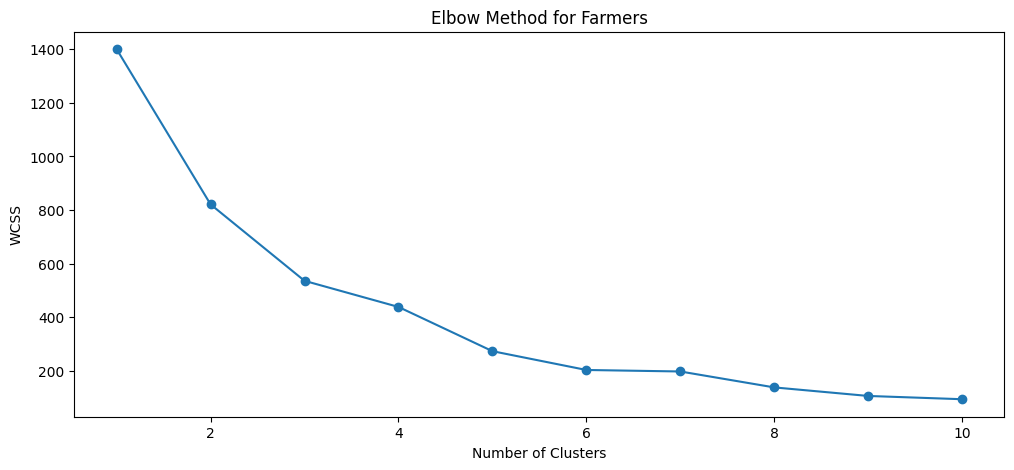

In [17]:
# Elbow method for farmers
wcss_farmers = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init="auto")
    kmeans.fit(farmer_features)
    wcss_farmers.append(kmeans.inertia_)

plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), wcss_farmers, marker='o')
plt.title('Elbow Method for Farmers')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

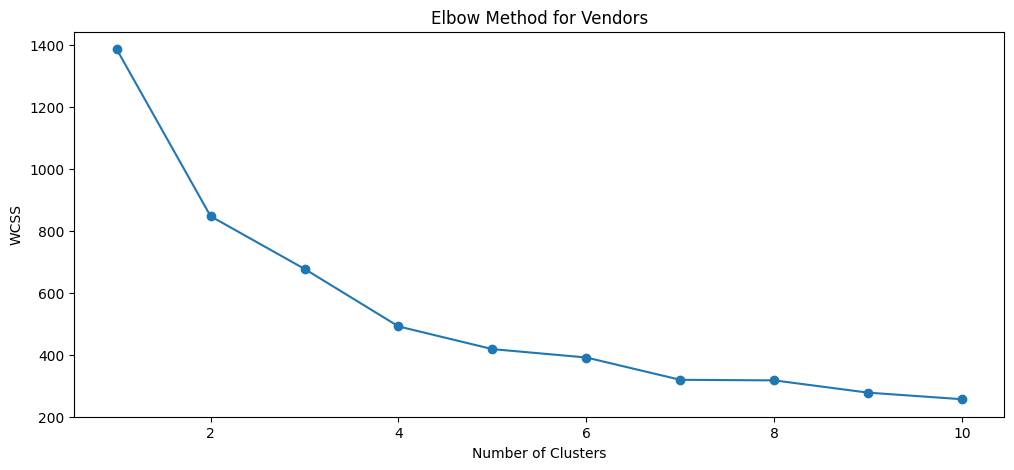

In [18]:
# Elbow method for vendors
wcss_vendors = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init="auto")
    kmeans.fit(vendor_features)
    wcss_vendors.append(kmeans.inertia_)

plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), wcss_vendors, marker='o')
plt.title('Elbow Method for Vendors')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [19]:
kmeans_farmers = KMeans(n_clusters=4, init='k-means++', random_state=42)
y_predict_farmers = kmeans_farmers.fit_predict(farmer_features)
y_predict_farmers

array([2, 0, 1, 3, 2, 2, 2, 0, 3, 2, 2, 1, 0, 2, 0, 0, 3, 1, 0, 0, 3, 2,
       1, 0, 1, 0, 1, 3, 1, 0, 1, 3, 0, 2, 0, 0, 0, 0, 3, 1, 2, 3, 2, 2,
       0, 3, 0, 0, 0, 1, 1, 1, 0, 2, 0, 3, 2, 2, 2, 0, 2, 1, 1, 0, 2, 0,
       3, 1, 1, 3, 1, 3, 2, 2, 2, 1, 0, 3, 0, 3, 2, 2, 3, 0, 2, 2, 1, 0,
       3, 0, 0, 1, 0, 1, 2, 0, 2], dtype=int32)

In [20]:
kmeans_vendors = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_predict_vendors = kmeans_vendors.fit_predict(vendor_features)
y_predict_vendors

array([4, 1, 3, 4, 3, 2, 2, 4, 2, 4, 2, 2, 3, 3, 2, 4, 4, 1, 4, 1, 1, 0,
       1, 4, 4, 3, 2, 3, 4, 4, 0, 4, 0, 0, 3, 1, 2, 4, 1, 2, 2, 2, 1, 4,
       2, 4, 3, 0, 2, 3, 0, 1, 0, 3, 4, 0, 3, 2, 4, 1, 1, 2, 3, 1, 1, 2,
       3, 4, 2, 2, 3, 2, 2, 4, 3, 3, 1, 4, 4, 1, 1, 1], dtype=int32)

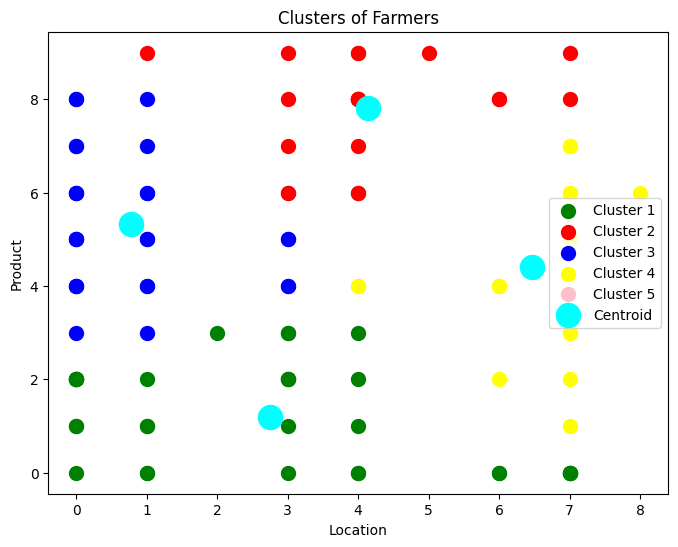

In [21]:
colors = ['green', 'red', 'blue', 'yellow', 'pink']

plt.figure(figsize=(8, 6))

for i in range(5):
    plt.scatter(
        farmer_features.values[y_predict_farmers == i, 0],
        farmer_features.values[y_predict_farmers == i, 1],
        s=100,
        c=colors[i % len(colors)],
        label=f'Cluster {i+1}'
    )

# Plot centroids
plt.scatter(
    kmeans_farmers.cluster_centers_[:, 0],
    kmeans_farmers.cluster_centers_[:, 1],
    s=300,
    c='cyan',
    label='Centroid'
)

plt.title("Clusters of Farmers")
plt.xlabel("Location")
plt.ylabel("Product")
plt.legend()
plt.show()

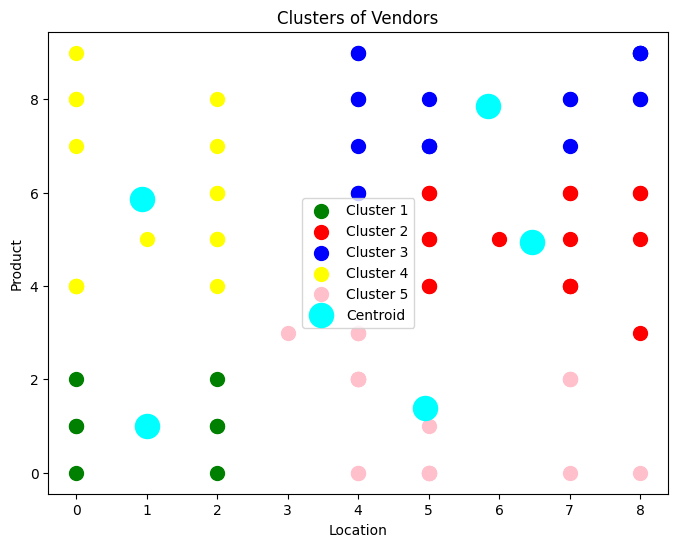

In [22]:
colors = ['green', 'red', 'blue', 'yellow', 'pink']

plt.figure(figsize=(8, 6))

for i in range(5):
    plt.scatter(
        vendor_features.values[y_predict_vendors == i, 0],
        vendor_features.values[y_predict_vendors == i, 1],
        s=100,
        c=colors[i % len(colors)],
        label=f'Cluster {i+1}'
    )

# Plot centroids
plt.scatter(
    kmeans_vendors.cluster_centers_[:, 0],
    kmeans_vendors.cluster_centers_[:, 1],
    s=300,
    c='cyan',
    label='Centroid'
)

plt.title("Clusters of Vendors")
plt.xlabel("Location")
plt.ylabel("Product")
plt.legend()
plt.show()


In [23]:
def predict_best_vendor(location, product):
    # Clean input
    location = location.strip()
    product = product.strip()

    # Ensure label encoders cover all data
    all_locations = pd.concat([farmers_df["location"], vendors_df["location"]])
    all_products = pd.concat([farmers_df["product"], vendors_df["product"]])

    label_encoder_location.fit(all_locations)
    label_encoder_product.fit(all_products)

    try:
        loc_encoded = label_encoder_location.transform([location])[0]
        prod_encoded = label_encoder_product.transform([product])[0]
    except ValueError:
        return "Invalid location or product: not found in training data."

    # Create farmer input features (no scaling)
    farmer_input = pd.DataFrame([[loc_encoded, prod_encoded]], columns=["location_encoded", "product_encoded"])
    farmer_cluster = kmeans_farmers.predict(farmer_input)[0]

    # Filter matching vendors
    matching_vendors = vendors_df[
        (vendors_df["location_encoded"] == loc_encoded) &
        (vendors_df["product_encoded"] == prod_encoded)
    ]

    if len(matching_vendors) == 0:
        return "No matching vendors found for this location and product."

    # Sort vendors by reliability (desc), then price (asc)
    top_vendors = matching_vendors.sort_values(
        by=["reliability_score", "avg_price_quintal"],
        ascending=[False, True]
    ).head(5)

    # Return a list of top vendors
    return top_vendors[[
        "vendor_id", "name", "location", "product", "reliability_score", "avg_price_quintal"
    ]]


In [24]:
result = predict_best_vendor("Haryana", "Rice")

if isinstance(result, pd.DataFrame):
    print("Top Vendors:")
    print(result.to_string(index=False))
else:
    print(result)


Top Vendors:
vendor_id             name location product  reliability_score  avg_price_quintal
    V7007 Krishna Tradersx  Haryana    Rice           0.631335           0.119227
    V9443  Krishna Traders  Haryana    Rice           0.252884           1.241304
    V4328      FarmDirectx  Haryana    Rice           0.017984          -0.220250
    V3988      AgroSupplyx  Haryana    Rice           0.017984           0.273040


In [25]:
def predict_best_farmer(location, product):
    # Clean input
    location = location.strip()
    product = product.strip()

    # Ensure label encoders are consistent
    all_locations = pd.concat([farmers_df["location"], vendors_df["location"]])
    all_products = pd.concat([farmers_df["product"], vendors_df["product"]])
    label_encoder_location.fit(all_locations)
    label_encoder_product.fit(all_products)

    try:
        loc_encoded = label_encoder_location.transform([location])[0]
        prod_encoded = label_encoder_product.transform([product])[0]
    except ValueError:
        return "Invalid location or product: not found in training data."

    # Farmer input for clustering
    farmer_input = pd.DataFrame([[loc_encoded, prod_encoded]], columns=["location_encoded", "product_encoded"])
    farmer_cluster = kmeans_farmers.predict(farmer_input)[0]

    # Predict clusters for all farmers (if not already added)
    farmers_df["kmeans_cluster"] = y_predict_farmers

    # Find matching farmers in the same cluster
    matching_farmers = farmers_df[
        (farmers_df["kmeans_cluster"] == farmer_cluster) &
        (farmers_df["product_encoded"] == prod_encoded) &
        (farmers_df["location_encoded"] == loc_encoded)
    ]

    if matching_farmers.empty:
        return "No suitable farmers found."

    # Return top 5 (just arbitrarily taking first 5 matching)
    return matching_farmers[["farmer_id", "name", "location", "product"]].head(5)


In [26]:
result = predict_best_farmer("Haryana", "Rice")

if isinstance(result, pd.DataFrame):
    print("Top 5 Suitable Farmers:")
    print(result.to_string(index=False))
else:
    print(result)


Top 5 Suitable Farmers:
farmer_id   name location product
    F8035 Rajesh  Haryana    Rice
    F8346  Ravix  Haryana    Rice
    F8850 Manojx  Haryana    Rice
